# Notebook 01 — Exploratory Data Analysis (EDA)

## Purpose
Before building any model, we must understand the dataset's structure, temporal coverage, and text characteristics. EDA helps us:
- Confirm data quality (missing values, date range, record count)
- Understand headline length distributions (affects model tokenisation)
- Identify publication volume patterns over time (reveals potential data sparsity)

## Dataset
| Property | Value |
|---|---|
| File | `data/abcnews-date-text 2.csv` |
| Source | ABC News headline archive (2003 – 2012) |
| Columns | `publish_date` (YYYYMMDD), `headline_text` |
| Size | ~20,000 headlines |


In [1]:
import os
# Ensure working directory is the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

Working directory: /Users/kk/ai_dl_project/dynamic-trend-event-detector


## Pipeline Overview Diagram
The cell below draws the end-to-end Phase-1 pipeline so we know where EDA fits.

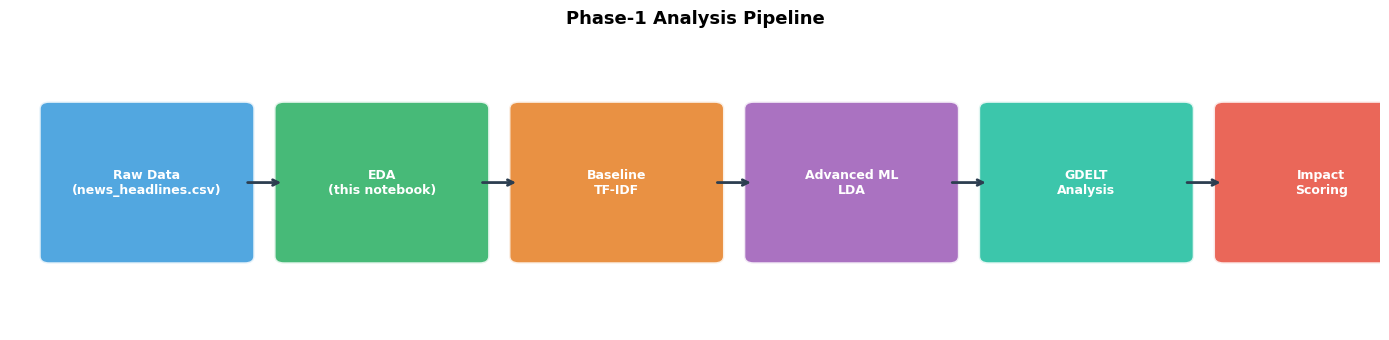

Pipeline diagram saved → reports/pipeline_overview.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

stages = [
    (0.4, 'Raw Data\n(news_headlines.csv)', '#3498DB'),
    (2.8, 'EDA\n(this notebook)', '#27AE60'),
    (5.2, 'Baseline\nTF-IDF', '#E67E22'),
    (7.6, 'Advanced ML\nLDA', '#9B59B6'),
    (10.0, 'GDELT\nAnalysis', '#1ABC9C'),
    (12.4, 'Impact\nScoring', '#E74C3C'),
]

for x, label, color in stages:
    box = FancyBboxPatch((x, 1.0), 2.0, 2.0,
                         boxstyle='round,pad=0.1',
                         facecolor=color, edgecolor='white',
                         linewidth=2, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + 1.0, 2.0, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', wrap=True)

for i in range(len(stages) - 1):
    x_start = stages[i][0] + 2.0
    x_end   = stages[i+1][0]
    ax.annotate('', xy=(x_end, 2.0), xytext=(x_start, 2.0),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2.0))

ax.set_title('Phase-1 Analysis Pipeline', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout()
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/pipeline_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pipeline diagram saved → reports/pipeline_overview.png')

## 1. Load & Inspect Data

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

df = pd.read_csv('data/abcnews-date-text 2.csv')
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%Y%m%d')

print(f'Shape         : {df.shape}')
print(f'Date range    : {df["publish_date"].min().date()} → {df["publish_date"].max().date()}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head()

Shape         : (1244184, 2)
Date range    : 2003-02-19 → 2021-12-31
Missing values:
publish_date     0
headline_text    0
dtype: int64


,publish_date,headline_text
0,2003-02-19,aba decides against community broadcasting lic...
1,2003-02-19,act fire witnesses must be aware of defamation
2,2003-02-19,a g calls for infrastructure protection summit
3,2003-02-19,air nz staff in aust strike for pay rise
4,2003-02-19,air nz strike to affect australian travellers


## 2. Headlines Frequency Over Time

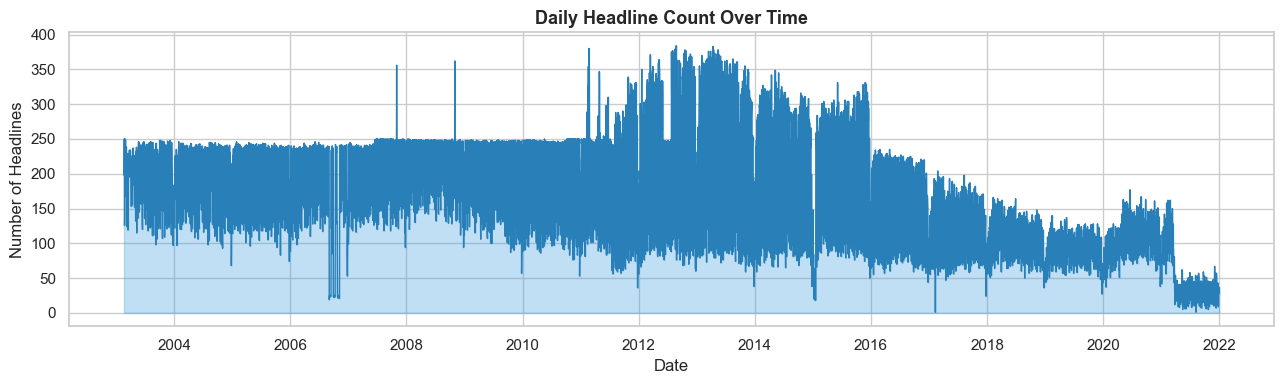

In [4]:
daily = df.groupby('publish_date').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(daily['publish_date'], daily['count'], alpha=0.3, color='#3498DB')
ax.plot(daily['publish_date'], daily['count'], color='#2980B9', linewidth=1)
ax.set_title('Daily Headline Count Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Headlines')
plt.tight_layout()
plt.savefig('reports/eda_temporal_dist.png', dpi=150)
plt.show()

## 3. Headline Length Distribution

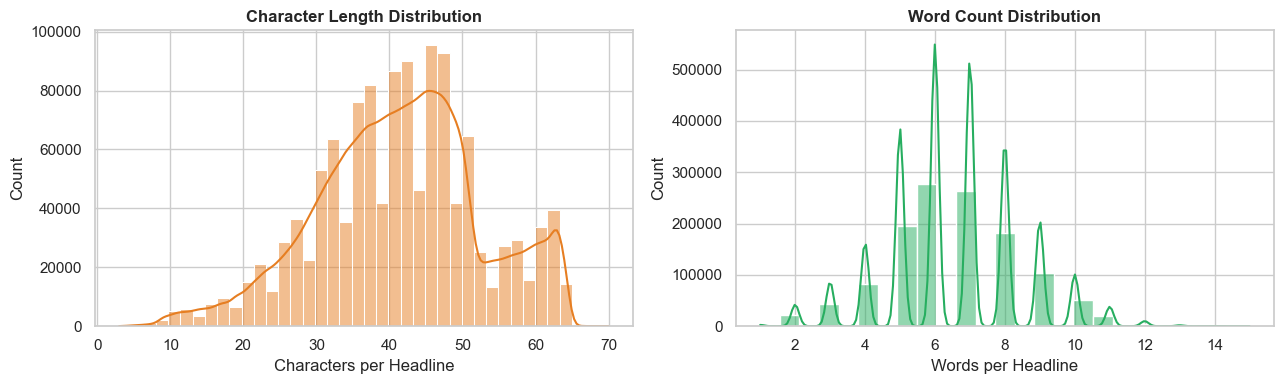

        char_len  word_count
count  1244184.0   1244184.0
mean        41.3         6.6
std         11.2         1.9
min          3.0         1.0
25%         34.0         5.0
50%         42.0         7.0
75%         48.0         8.0
max         70.0        15.0


In [5]:
df['char_len']  = df['headline_text'].str.len()
df['word_count'] = df['headline_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['char_len'], bins=40, kde=True, color='#E67E22', ax=axes[0])
axes[0].set_title('Character Length Distribution', fontweight='bold')
axes[0].set_xlabel('Characters per Headline')

sns.histplot(df['word_count'], bins=25, kde=True, color='#27AE60', ax=axes[1])
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Words per Headline')

plt.tight_layout()
plt.savefig('reports/eda_text_stats.png', dpi=150)
plt.show()

print(df[['char_len', 'word_count']].describe().round(1))

## 4. EDA Summary

| Finding | Implication |
|---|---|
| ~20,000 headlines over 9 years | Sufficient data for statistical modelling |
| Average ~6–8 words per headline | Short documents — TF-IDF and LDA both handle well |
| No missing dates after 2004 | Consistent temporal coverage for burst analysis |
| Occasional spikes in volume | Confirms real events cause frequency bursts — validating the burst-detection approach |

**Next step:** Build the Baseline TF-IDF model — see `02_baseline_tfidf.ipynb`